## Uber Supply and Demand Data Analysis

Kartheek Nistala - https://krtk.xyz

Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Read and Convert CSV file to DataFrame


In [2]:
df_raw = pd.read_csv(r'C:\Users\krtk2\Documents\Placement\Uber Analysis\Data\Uber_Data.csv')
df_raw.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/7/2016 11:51,11/7/2016 13:00
1,867,Airport,1.0,Trip Completed,11/7/2016 17:57,11/7/2016 18:47
2,1807,City,1.0,Trip Completed,12/7/2016 9:17,12/7/2016 9:58
3,2532,Airport,1.0,Trip Completed,12/7/2016 21:08,12/7/2016 22:03
4,3112,City,1.0,Trip Completed,13-07-2016 08:33:16,13-07-2016 09:25:47


Converting request timestamp to datetime format

In [3]:
df_uber = df_raw.copy()

df_uber['Request timestamp'] = pd.to_datetime(
    df_raw['Request timestamp'],
    format="mixed",
    dayfirst=True
)

df_uber['Drop timestamp'] = pd.to_datetime(
    df_raw['Drop timestamp'],
    format="mixed",
    dayfirst=True
)

Replacing blank columns and Removing unecessary columns

In [4]:
df_uber.columns = [col.replace(' ', '_') for col in df_uber.columns]

df_uber=df_uber.drop(['Request_id','Driver_id','Drop_timestamp'], axis=1)
df_uber.head()

,Pickup_point,Status,Request_timestamp
0,Airport,Trip Completed,2016-07-11 11:51:00
1,Airport,Trip Completed,2016-07-11 17:57:00
2,City,Trip Completed,2016-07-12 09:17:00
3,Airport,Trip Completed,2016-07-12 21:08:00
4,City,Trip Completed,2016-07-13 08:33:16


Checking the unique values

In [5]:
df_uber['Status'].unique()

array(['Trip Completed', 'Cancelled', 'No Cars Available'], dtype=object)

Dividing the trips into 6 sessions by their request timestamp

In [6]:

session_labels=['Late Night','Early Morning','Late Morning','Afternoon','Evening','Night']
df_uber=df_uber.assign(session=pd.cut(df_uber.Request_timestamp.dt.hour,[-1,4,8,12,16,20,24],labels=session_labels))
df_uber.head()

,Pickup_point,Status,Request_timestamp,session
0,Airport,Trip Completed,2016-07-11 11:51:00,Late Morning
1,Airport,Trip Completed,2016-07-11 17:57:00,Evening
2,City,Trip Completed,2016-07-12 09:17:00,Late Morning
3,Airport,Trip Completed,2016-07-12 21:08:00,Night
4,City,Trip Completed,2016-07-13 08:33:16,Early Morning


Plotting frequency of all "Trip Status" over the day to identify problem

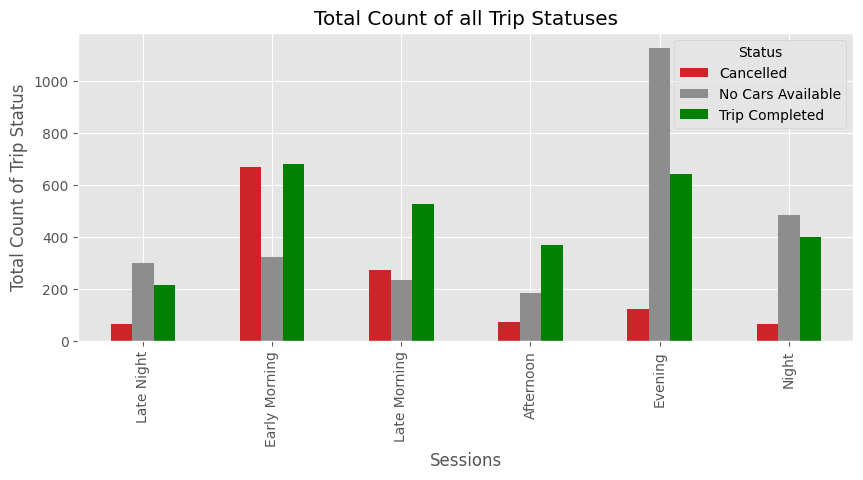

In [7]:
plt.style.use('ggplot')
colors = ["#CC2529", "#8E8D8D", "#008000"]
df_uber.groupby(
    ['session', 'Status'],
    observed=True
).Status.count().unstack().plot.bar(
    legend=True,
    figsize=(10, 4),
    color=colors
)
plt.title('Total Count of all Trip Statuses')
plt.xlabel('Sessions')
plt.ylabel('Total Count of Trip Status')
plt.show()


Filtering out only "Canclled" trips

In [8]:
df_tripscancelled=df_uber[df_uber["Status"].str.contains('Cancelled')==True]
df_tripscancelled=df_tripscancelled.reset_index(drop=True)
df_tripscancelled.head()

,Pickup_point,Status,Request_timestamp,session
0,City,Cancelled,2016-07-13 06:08:41,Early Morning
1,City,Cancelled,2016-07-14 17:07:58,Evening
2,Airport,Cancelled,2016-07-14 20:51:37,Evening
3,City,Cancelled,2016-07-15 10:12:40,Late Morning
4,Airport,Cancelled,2016-07-12 19:14:00,Evening


Plotting frequency of all "Cancelled" trips over the day to identify problem

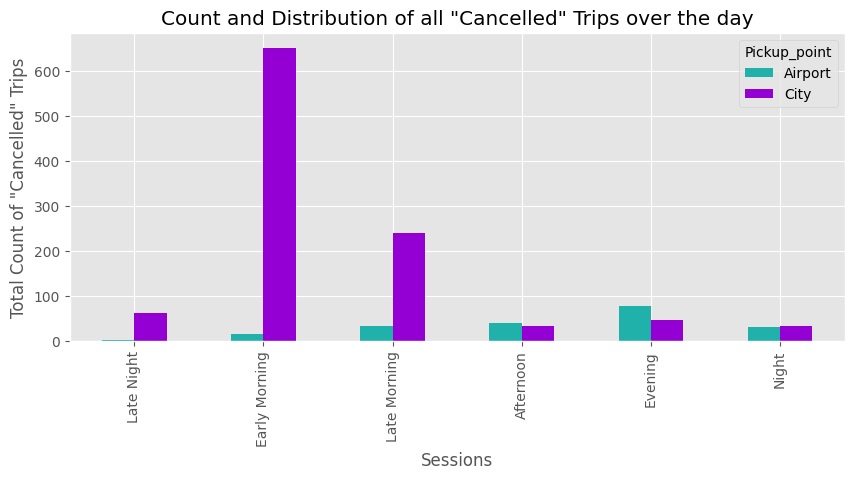

In [9]:
plt.style.use('ggplot')
colors = ["#20B2AA", "#9400D3"]
df_tripscancelled.groupby(
    ['session', 'Pickup_point'],
    observed=True
).Pickup_point.count().unstack().plot.bar(
    legend=True,
    figsize=(10,4),
    color=colors
)
plt.title('Count and Distribution of all "Cancelled" Trips over the day')
plt.xlabel('Sessions')
plt.ylabel('Total Count of "Cancelled" Trips')
plt.show()

Filtering out only "Canclled" trips and all "No Car Available" trips over the day

In [10]:
df_nocar=df_uber[df_uber["Status"].str.contains('No Car')==True]
df_nocar=df_nocar.reset_index(drop=True)
df_nocar.head()

,Pickup_point,Status,Request_timestamp,session
0,City,No Cars Available,2016-07-11 00:02:00,Late Night
1,City,No Cars Available,2016-07-11 00:06:00,Late Night
2,City,No Cars Available,2016-07-11 00:09:00,Late Night
3,Airport,No Cars Available,2016-07-11 00:23:00,Late Night
4,Airport,No Cars Available,2016-07-11 00:30:00,Late Night


Plotting frequency of all "No Car Available" trips all over the day

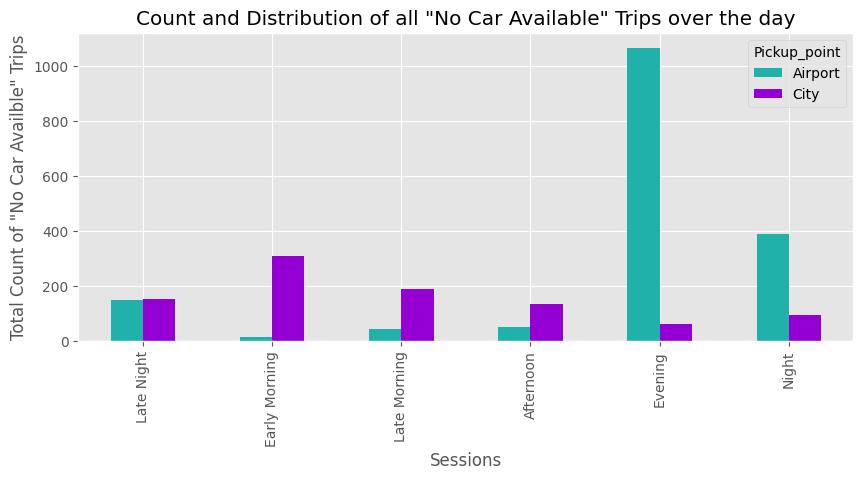

In [12]:
plt.style.use('ggplot')
colors = ["#20B2AA", "#9400D3"]
df_nocar.groupby(['session','Pickup_point'],observed=True).Pickup_point.count().unstack().plot.bar(legend=True, figsize=(10,4), color=colors)
plt.title('Count and Distribution of all "No Car Available" Trips over the day')
plt.xlabel('Sessions')
plt.ylabel('Total Count of "No Car Availble" Trips')
plt.show()

Filtering out trips in the "City to Airport" route. Pick-up-Point - City

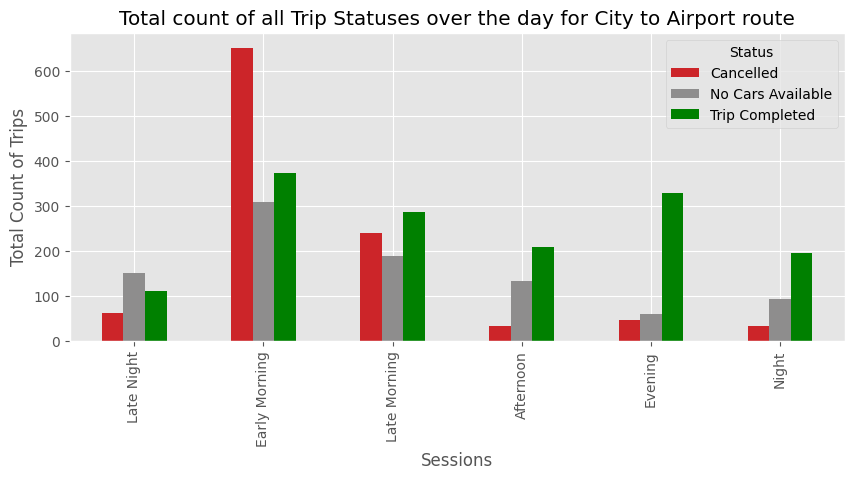

In [11]:
df_citytoairport=df_uber[df_uber["Pickup_point"].str.contains('City')==True]
plt.style.use('ggplot')
colors = ["#CC2529", "#8E8D8D","#008000"]
df_citytoairport.groupby(['session','Status'],observed = True).Status.count().unstack().plot.bar(legend=True, figsize=(10,4), color=colors)
plt.title('Total count of all Trip Statuses over the day for City to Airport route')
plt.xlabel('Sessions')
plt.ylabel('Total Count of Trips')
plt.show()

Filtering out trips in the "Airport to City" route. Pick-up-Point - Airport

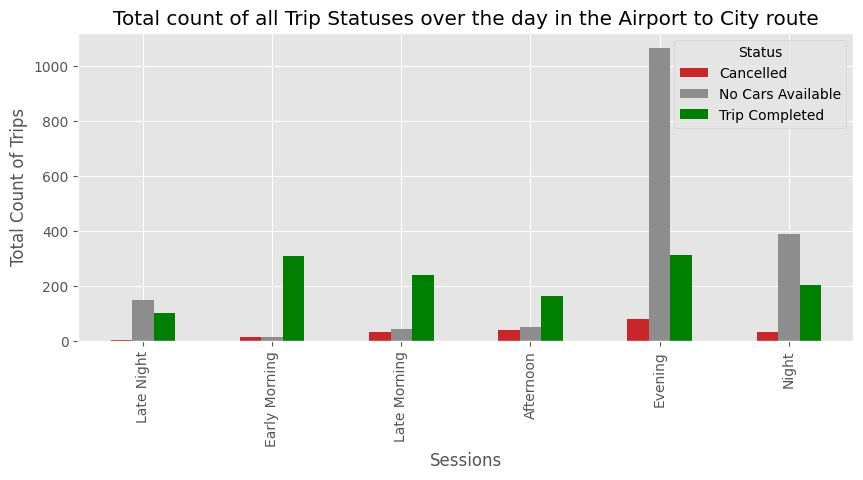

In [13]:
df_airporttocity=df_uber[df_uber["Pickup_point"].str.contains('Airport')==True]
plt.style.use('ggplot')
colors = ["#CC2529", "#8E8D8D","#008000"]
df_airporttocity.groupby(['session','Status'],observed = True).Status.count().unstack().plot.bar(legend=True, figsize=(10,4), color=colors)
plt.title('Total count of all Trip Statuses over the day in the Airport to City route')
plt.xlabel('Sessions')
plt.ylabel('Total Count of Trips')
plt.show()

In [36]:
df_uber['supply_demand'] = ['Supply' if x == 'Trip Completed' else 'Demand' for x in df_uber['Status']]
df_uber.head()

,Pickup_point,Status,Request_timestamp,session,supply_demand
0,Airport,Trip Completed,2016-07-11 11:51:00,Late Morning,Supply
1,Airport,Trip Completed,2016-07-11 17:57:00,Evening,Supply
2,City,Trip Completed,2016-07-12 09:17:00,Late Morning,Supply
3,Airport,Trip Completed,2016-07-12 21:08:00,Night,Supply
4,City,Trip Completed,2016-07-13 08:33:16,Early Morning,Supply


Plotting Supply and Demand on the "City to Airport" route

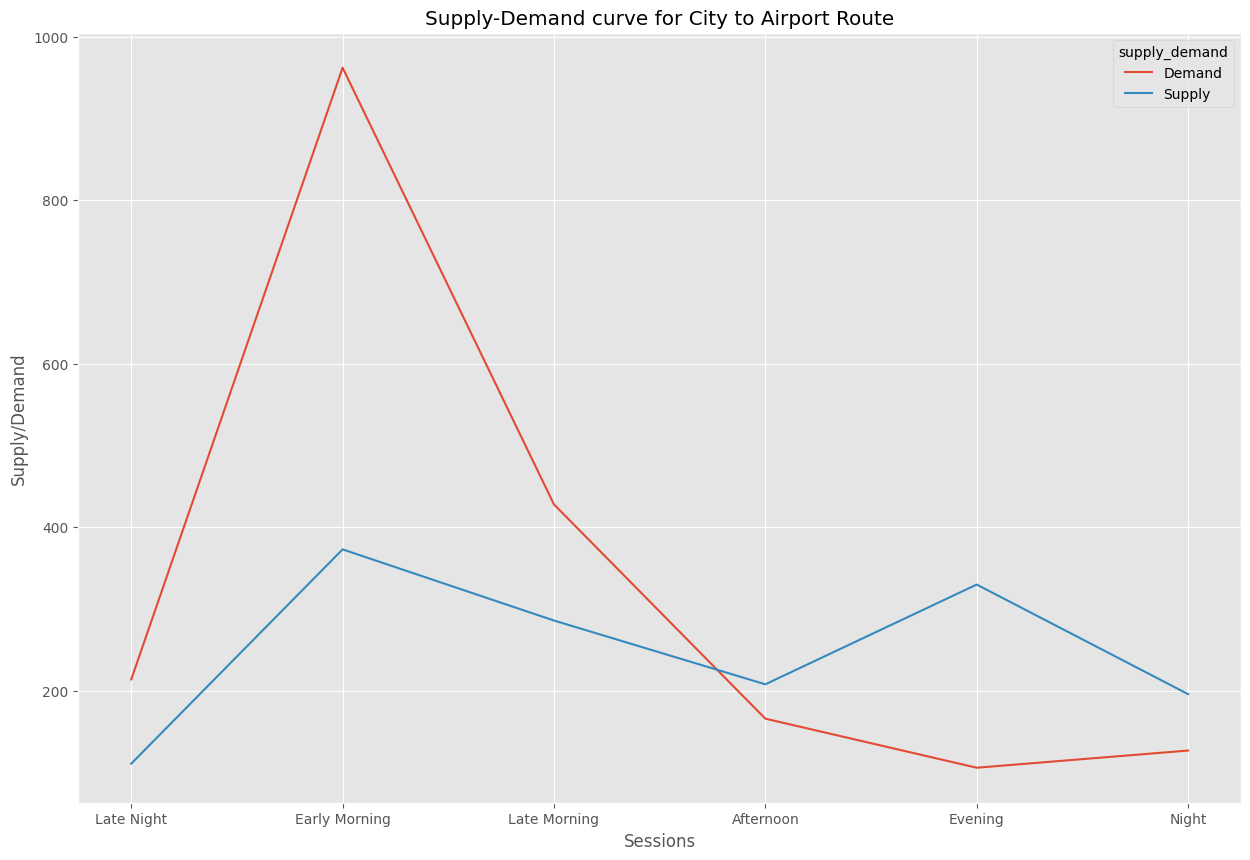

In [38]:
df_citytoairport_supplydemand=df_uber[df_uber["Pickup_point"].str.contains('City')==True]
plt.style.use('ggplot')
df_citytoairport_supplydemand.groupby(['session','supply_demand'],observed = True).supply_demand.count().unstack().plot.line(legend=True, figsize=(15,10))
plt.title('Supply-Demand curve for City to Airport Route')
plt.xlabel('Sessions')
plt.ylabel('Supply/Demand')
plt.show()

Plotting Supply and Demand on the "Airport to City" route

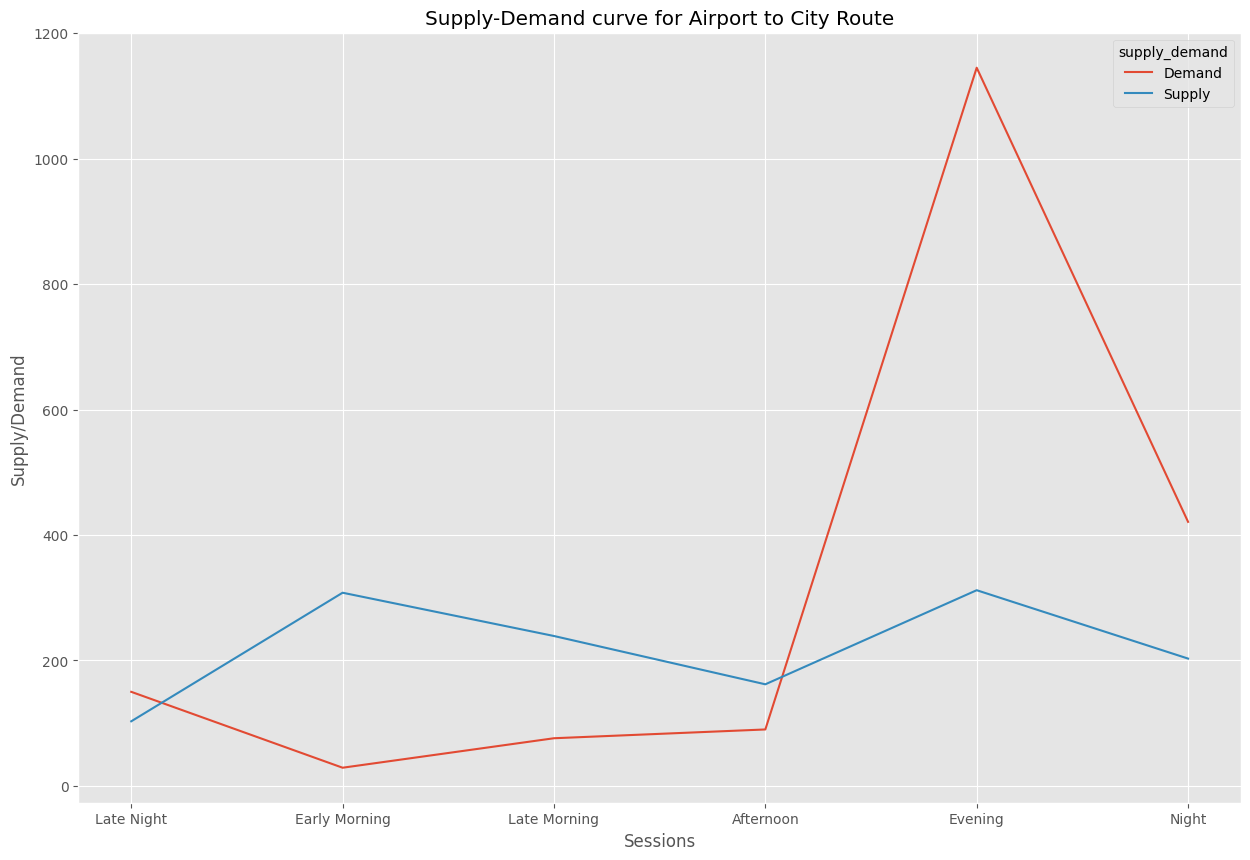

In [39]:
df_airporttocity_supplydemand=df_uber[df_uber["Pickup_point"].str.contains('Airport')==True]
plt.style.use('ggplot')
df_airporttocity_supplydemand.groupby(['session','supply_demand'],observed = True).supply_demand.count().unstack().plot.line(legend=True, figsize=(15,10))
plt.title('Supply-Demand curve for Airport to City Route')
plt.xlabel('Sessions')
plt.ylabel('Supply/Demand')
plt.show()